In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
from scipy import constants
import math

In [2]:
sim = Simulation("ChargeDiffusion")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]
workDir = os.environ["PLATO_WORKDIR"]

sim["ObservingParameters/NumExposures"] = 1
dim = 9
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim
numSubPixels = sim["SubField/SubPixels"]

# One full-frame exposure

sim["CCD/IncludeConvolution"] = "no"
sim["PSF/Model"] = "MappedGaussian"

ccdCode = '2'
sim["CCD/Position"] = ccdCode

pixelSize = sim["CCD/PixelSize"] * constants.micro / constants.milli

ra, dec = rf.pixelToSkyCoordinates(sim, ccdCode, (dim) / 2, (dim) / 2)

ra = math.degrees(ra)
dec = math.degrees(dec)

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

myFile = open(starCatalogFilename, "w")
myFile.write("# RA DEC Vmag starID\n")
myFile.write("{0}  {1}  {2}  {3}\n".format(ra, dec, 12.5, 1))
myFile.close()

sim["ControlHDF5Content/WriteSubPixelImages"] = True

In [3]:
sim["CCD/IncludeConvolution"] = "yes"
sim["PSF/Model"] = "MappedGaussian"

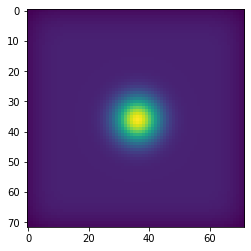

In [4]:
imageWithoutCD = sim.run(removeOutputFile = True).getSubPixelImage(0)
plt.imshow(imageWithoutCD)

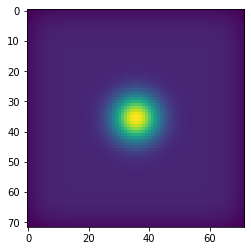

In [5]:
sim["PSF/MappedGaussian/IncludeChargeDiffusion"] = "yes"
imageWithCD = sim.run(removeOutputFile = True).getSubPixelImage(0)
plt.imshow(imageWithCD)

In [6]:
dim = dim * sim["SubField/SubPixels"]

sigma = sim["PSF/MappedGaussian/Sigma"]
params = fitGaussian2D(imageWithoutCD, np.max(imageWithoutCD), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
print("Sigma:", params[3] / numSubPixels)
print("vs.", sigma)

Sigma: 0.642717354926769
vs. 0.639


In [7]:
sigma = math.sqrt(math.pow(sim["PSF/MappedGaussian/Sigma"], 2) + math.pow(sim["PSF/MappedGaussian/ChargeDiffusionStrength"], 2))
params = fitGaussian2D(imageWithCD, np.max(imageWithCD), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
print("Sigma:", params[3] / numSubPixels)
print("vs.", sigma)

Sigma: 0.6748352976603904
vs. 0.6695677710284449


In [8]:
print(params)

[568.79046542  35.49999995  35.50000014   5.39868238   5.39868244]
